# Task 1: Comparative Analysis of Dimensional Measurement Systems

---

This section evaluates the performance and capability of two manual measurement instruments: the Digital Micrometer and the Vernier Micrometer.The primary objective is to analyze dimensional data to determine system effectiveness in terms of resolution and repeatability.

---

##  Objectives & Scope
This analysis is structured to fulfill the specific requirements of Task 1 as outlined in the MN5610 assessment brief:

* **`Capability Assessment`**: Evaluating the measurement system's performance by quantifying Resolution and Repeatability based on the data collected by two operators.

* **`Statistical Validation`**: Executing a Two-way ANOVA supplemented by Manual Calculations to identify significant trends and source variations between operators and instruments.

* **`Operational Procedure & Uncertainty`**: Detailing the standard procedure for micrometer usage and investigating factors that contribute to measurement uncertainty, such as environmental temperature ($20 \pm 1^\circ C$) and human influence.

* **`Minimization & Control`**: Proposing strategies to minimize or control identified uncertainty contributors to ensure data integrity and traceability.

* **`Instrument Appraisal`**: Providing a formal appraisal of the suitability of both Digital and Vernier micrometers for small-batch inspections against specified component tolerances.

---

##  Technical Specifications
The measurement of the **measurand** (cylinder diameter) followed these experimental parameters:

| Feature | Description |
| :--- | :--- |
| **Measurand** | External Diameter of a Cylinder  |
| **Instruments** | Digital Micrometer vs. Vernier Micrometer  |
| **Operators** | Two Operators (10 repetitions each)  |
| **Environment** | Controlled Metrology Laboratory ($20 \pm 1^\circ C$)  |
| **Total Samples** | 40 Observations |

---

##  Analytical Methodology
The quantitative evaluation is implemented through a structured statistical workflow:

1.  **`Data Preprocessing`**: Converting raw experimental data into a long-format structure for robust modeling.

2.  **`Assumption Verification`**:

    * **Normality**: Testing residuals using Shapiro-Wilk and Q-Q Plots to ensure a Gaussian distribution.

    * **Homogeneity**: Checking for equal variance across groups using **Levene’s Test**.

3.  **`Variance Analysis`**: Executing Two-way ANOVA to extract $F$-statistics and $p$-values for operator and instrument effects.

4.  **`Visual Interpretation`**: Utilizing Interaction Plots and Boxplots to visualize trends and measurement stability.

---

# STEP 1: Data Ingestion & Preprocessing

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


# 1.1 Read Excel File
df_raw = pd.read_excel('cylineder_measurements.xlsx')


# 1.2 change column names to reflect the actual data (since columns 2 and 3 are the measurements)
df_raw.columns = ['Operator', 'Digital', 'Vernier']

# 1.3 Transform Wide -> Long Format using pd.melt()
df = pd.melt(df_raw, 
             id_vars=['Operator'],               # Keep the Operator column as is
             value_vars=['Digital', 'Vernier'],  # Capture the two measurement columns
             var_name='Instrument',              # Set the name of the new column for instrument type
             value_name='Measurement')           # Set the name of the new column for measurement values

print("--- Data Preview  ---")
print(df.head())
print(f"\n row count: {len(df)} \n")

--- Data Preview (Cleaned Long Format) ---
  Operator Instrument  Measurement
0      Op1    Digital       22.214
1      Op1    Digital       22.212
2      Op1    Digital       22.211
3      Op1    Digital       22.211
4      Op1    Digital       22.210

 row count: 40 



## STEP 2: Assumption Checks

In [ ]:
# ==========================================
# STEP 2: Assumption Checks
# ==========================================

# Create  Model to get Residuals (Error Terms)
model = ols('Measurement ~ C(Operator) * C(Instrument)', data=df).fit()
residuals = model.resid

print("--- Assumption Checks ---")
# 2.1 Normality Test (Shapiro-Wilk)
shapiro_test = stats.shapiro(residuals)
print(f"1. Shapiro-Wilk Test: W={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# 2.2 Homogeneity of Variance (Levene's Test)
dig = df[df['Instrument'] == 'Digital']['Measurement']
ver = df[df['Instrument'] == 'Vernier']['Measurement']
levene_test = stats.levene(dig, ver)
print(f"2. Levene's Test: W={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}\n")


--- Assumption Checks ---
1. Shapiro-Wilk Test: W=0.9524, p-value=0.0920
2. Levene's Test: W=3.0116, p-value=0.0908



Count of Digital: 20
Count of Vernier: 20


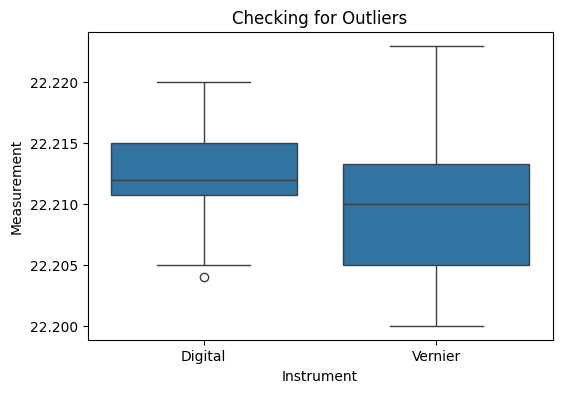

In [ ]:
print("Count of Digital:", len(dig))
print("Count of Vernier:", len(ver))

#  Boxplot to visually check for outliers
plt.figure(figsize=(6,4))
sns.boxplot(x='Instrument', y='Measurement', data=df)
plt.title("Checking for Outliers")
plt.show()

## STEP 3: ANOVA Results

In [48]:
# --- STEP 3: ANOVA Results (Formatted) ---
anova_table = sm.stats.anova_lm(model, typ=2)

# format the ANOVA table to 6 decimal places for better readability
formatted_anova = anova_table.copy()
pd.options.display.float_format = '{:.6f}'.format

print("--- FINAL ANOVA TABLE ---")
display(formatted_anova)

--- FINAL ANOVA TABLE ---


,sum_sq,df,F,PR(>F)
C(Operator),0.000010,1.000000,0.373379,0.545007
C(Instrument),0.000053,1.000000,1.986413,0.167297
C(Operator):C(Instrument),0.000026,1.000000,0.971526,0.330879
Residual,0.000955,36.000000,NaN,NaN


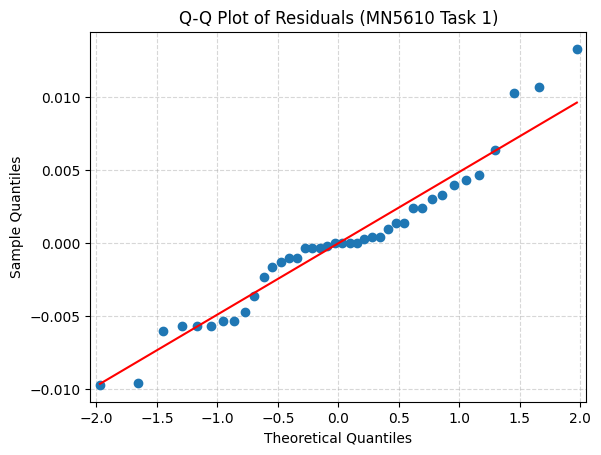

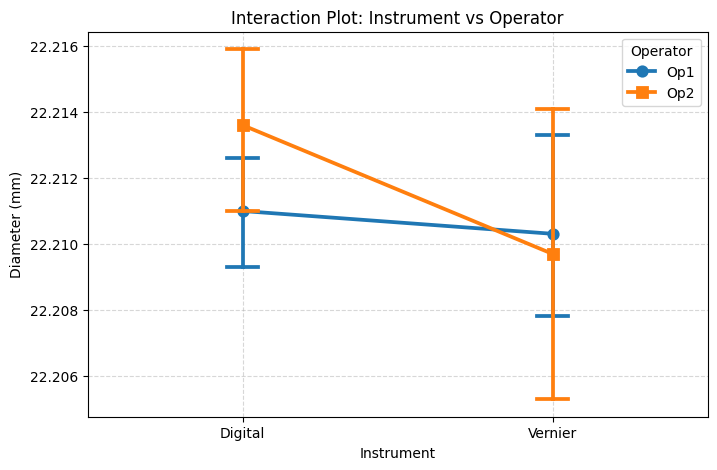

In [50]:
# ==========================================
# STEP 4: Visualization for Assumption Checks & Interaction
# ==========================================

# กราฟที่ 1: Q-Q Plot for Normality 
fig1 = sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals (MN5610 Task 1)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# กราฟที่ 2: Interaction Plot
plt.figure(figsize=(8, 5))
sns.pointplot(x='Instrument', y='Measurement', hue='Operator', data=df, capsize=.1, markers=['o', 's'])
plt.title("Interaction Plot: Instrument vs Operator")
plt.ylabel("Diameter (mm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()